In [1]:
from neuromodes.io import fetch_surf, fetch_map
from neuromodes import EigenSolver
from neuromodes.mesh import unmask_data
import numpy as np

In [2]:
surf, medmask = fetch_surf()
hetero = fetch_map('fcgradient1')

In [9]:
alphas = [0]
parcs = np.empty((medmask.sum(), len(alphas)), dtype=int)
for i, alpha in enumerate(alphas):
    parcs[:, i] = EigenSolver(
        surf, mask=medmask, hetero=hetero, alpha=alpha
        ).make_parcellation(10, seed=0)

c:\Users\ipop0003\neuromodes\neuromodes\eigen.py:534: UserWarning: alpha is set to 0, meaning hetero will have no effect.
  warn("alpha is set to 0, meaning hetero will have no effect.")
c:\Users\ipop0003\neuromodes\neuromodes\eigen.py:537: UserWarning: Provided hetero is constant; scaling hetero to a vector of ones.
  warn("Provided hetero is constant; scaling hetero to a vector of ones.")
c:\Users\ipop0003\neuromodes\neuromodes\mesh.py:71: UserWarning: 1 vertices in the mask are not part of any kept element and will be removed.
  warn(f'{np.sum(~referenced)} vertices in the mask are not part of any kept element and '


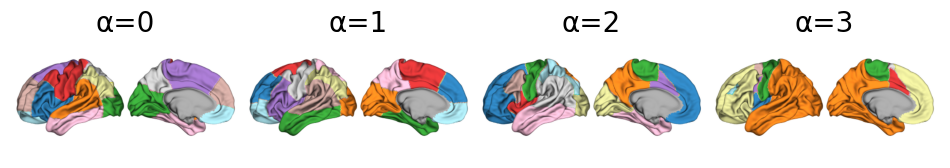

In [ ]:
from nsbutils.plotting import plot_surf
from importlib.resources import files

lh_surfpath = files('neuromodes.data') / 'sp-human_tpl-fsLR_den-32k_hemi-L_midthickness.surf.gii'
plot_surf(lh_surfpath, unmask_data(parcs, medmask), cmap='tab20', labels=['α=0', 'α=1', 'α=2', 'α=3'])

In [16]:
solver.plot(parcs[:,0], cmap='tab20')

<class 'plotly.graph_objs._figure.Figure'>


In [6]:
# plot emode 2 under different alpha
alphas = [0, 1, 5, 10]
parcs = np.empty((medmask.sum(), len(alphas)), dtype=int)
for i, alpha in enumerate(alphas):
    solver = EigenSolver(
        surf, mask=medmask, hetero=hetero, alpha=alpha
        ).solve(2)

    fig = solver.plot(data=solver.emodes[:, -1])
    fig.show()

c:\Users\ipop0003\neuromodes\neuromodes\eigen.py:532: UserWarning: alpha is set to 0, meaning hetero will have no effect.
  warn("alpha is set to 0, meaning hetero will have no effect.")


KeyboardInterrupt: 

In [3]:
# test plotting method
solver = EigenSolver(surf, mask=medmask).solve(10)

In [4]:
fig = solver.plot(data=solver.emodes[:, -1])

# save fig to png
fig.write_image('test_plot.png')

In [5]:
# Test repeatedly scaling heteromap
from neuromodes.eigen import scale_hetero

hetero_s1 = scale_hetero(hetero)
hetero_s2 = scale_hetero(hetero)
hetero_s3 = scale_hetero(hetero)
hetero_s4 = scale_hetero(hetero)

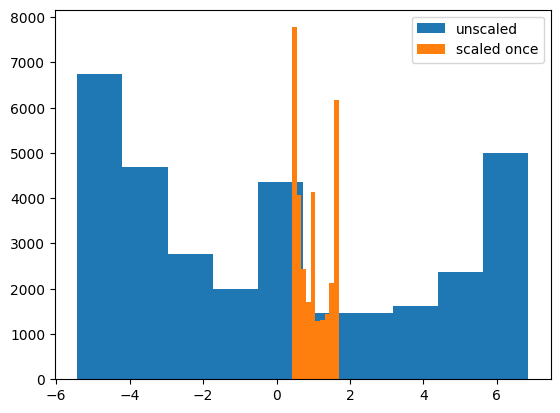

In [10]:
# plot distributions
import matplotlib.pyplot as plt

plt.hist(hetero, label='unscaled')
plt.hist(hetero_s1, label='scaled once')
# plt.hist(hetero_s2, label='scaled twice')
# plt.hist(hetero_s3, label='scaled thrice')
# plt.hist(hetero_s4, label='scaled frice')
plt.legend()
plt.show()